# **Notebook: Clustering the data**

## Table of Contents
* [Importing Libraries](#importing_libraries)
* [Data Loading](#loading_data)
* [Calculate Distances](#calculate_distances)
    * [Helper Functions](#helper_function)
    * [Distance to Geometry Points](#distance_to_geometry_points)
    * [Distance to Geometry Polygons](#distance_to_geometry_polygons)
    * [Compute Final Distances](#compute_final_distances)
* [Other Factors](#other_factors)
    * [Air Pollution](#air_pollution)
* [Quality of Life Index](#compute_qol_index)


### Imports <a class="anchor" id="importing_libraries"></a>

In [80]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
import pandas as pd
from shapely.ops import unary_union
import contextily as cx
import matplotlib.pyplot as plt
from tqdm import tqdm
import h3
import pandana
from shapely import Polygon, LineString
import h3
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from rasterio.plot import show
import rioxarray as rxr
import contextily as cx 
import seaborn as sns
import pandas as pd
import esda
from pysal.lib import weights
from splot.esda import (
    moran_scatterplot, lisa_cluster, plot_local_autocorrelation, plot_moran
)
from splot.libpysal import plot_spatial_weights
import geopandas as gpd
import numpy as np
import contextily as cx
import matplotlib.pyplot as plt

%matplotlib inline
ox.__version__

'1.9.4'

## Data Loading <a class="anchor" id="loading_data"></a>

In [51]:
CRS = "EPSG:25832"
CRS_ORIGINAL = "EPSG:4326"

In [24]:
df = gpd.read_file("../data/clean_data/qol_index.gpkg")

assert CRS == df.crs, "mismatched crs"

In [54]:
df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [53]:
df.to_crs(CRS_ORIGINAL, inplace=True)

In [55]:
df.head()

,osm_id,amenity,school_distance,transport_distance,hospital_distance,green_distance,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC,qol_index,geometry
0,23540747,apartments,431.964822,268.276004,725.711114,56.812642,12867,16.0,5460.0,0.9,365.385502,POINT (12.53998 55.69419)
1,24508264,apartments,889.700009,399.868751,1850.775750,61.283802,5313,12.0,8710.0,0.8,794.000184,POINT (12.49018 55.65712)
2,24508268,apartments,843.370460,353.539201,1896.216200,62.014092,31625,19.0,13000.0,1.1,783.193156,POINT (12.48962 55.65687)
3,24508270,apartments,732.946459,255.791200,1973.936199,75.207280,31843,20.0,12600.0,1.1,752.293338,POINT (12.48907 55.65661)
4,24513387,apartments,1058.237922,97.487996,1525.844752,29.245263,31381,14.0,15100.0,1.0,675.722099,POINT (12.49313 55.64761)


# Aggregation: h3

In [68]:
h3_level = 9

df_agg = df.copy()
df_agg['h3'] = df_agg.apply(lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, h3_level), axis=1)

df_agg.head()

,osm_id,amenity,school_distance,transport_distance,hospital_distance,green_distance,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC,qol_index,geometry,h3
0,23540747,apartments,431.964822,268.276004,725.711114,56.812642,12867,16.0,5460.0,0.9,365.385502,POINT (12.53998 55.69419),891f0583553ffff
1,24508264,apartments,889.700009,399.868751,1850.775750,61.283802,5313,12.0,8710.0,0.8,794.000184,POINT (12.49018 55.65712),891f0598d3bffff
2,24508268,apartments,843.370460,353.539201,1896.216200,62.014092,31625,19.0,13000.0,1.1,783.193156,POINT (12.48962 55.65687),891f0598d3bffff
3,24508270,apartments,732.946459,255.791200,1973.936199,75.207280,31843,20.0,12600.0,1.1,752.293338,POINT (12.48907 55.65661),891f0598d3bffff
4,24513387,apartments,1058.237922,97.487996,1525.844752,29.245263,31381,14.0,15100.0,1.0,675.722099,POINT (12.49313 55.64761),891f059898bffff


In [69]:
df_agg['h3'].nunique()

843

In [70]:
mean = df_agg.groupby(['h3']).qol_index.mean().to_frame('mean').reset_index()
mean.shape

(843, 2)

In [71]:
def add_geometry(row):
    points = h3.cell_to_boundary(row['h3'])
    return h3.LatLngPoly(points)

mean['geometry'] = mean.apply(add_geometry, axis=1)
mean.head()

,h3,mean,geometry
0,891f058000bffff,677.900420,<LatLngPoly: [6]>
1,891f0580043ffff,531.638503,<LatLngPoly: [6]>
2,891f0580047ffff,555.386397,<LatLngPoly: [6]>
3,891f058004bffff,331.762560,<LatLngPoly: [6]>
4,891f058004fffff,423.824152,<LatLngPoly: [6]>


In [72]:
gdf = gpd.GeoDataFrame(mean, crs=CRS_ORIGINAL)

In [79]:
gdf.explore(column='mean', legend=True)

<Axes: >

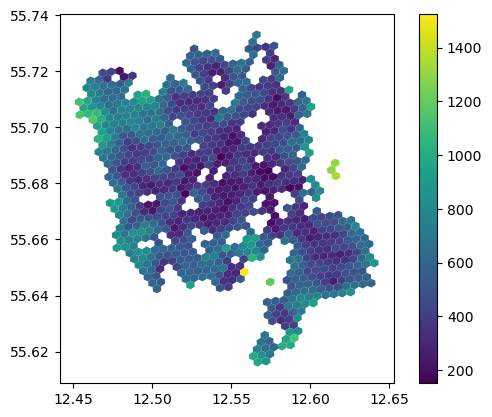

In [75]:
gdf.plot(column='mean', legend=True)

# Spatial Autocorrelation

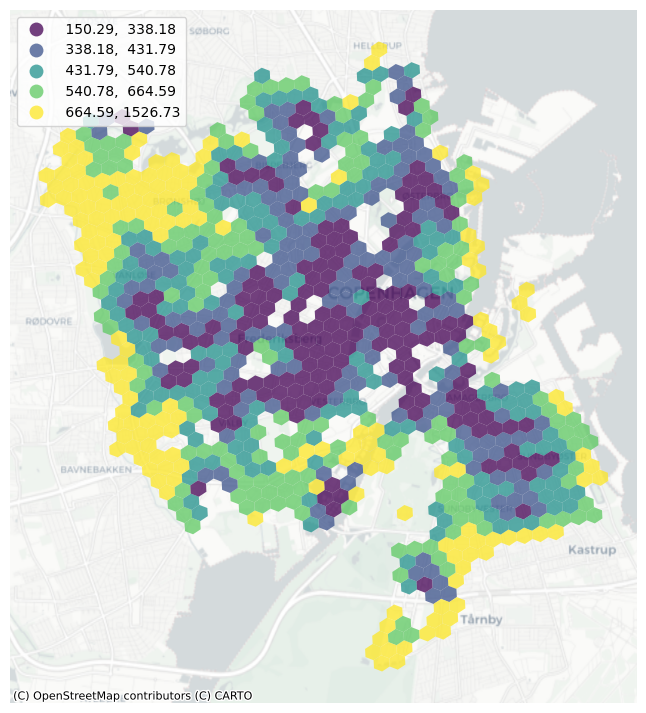

In [81]:
f, ax = plt.subplots(1, figsize=(9, 9))
gdf.plot(
    column="mean",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
cx.add_basemap(
    ax,
    crs=gdf.crs,
    source=cx.providers.CartoDB.Positron
)
ax.set_axis_off()

In [82]:
gdf

,h3,mean,geometry
0,891f058000bffff,677.900420,"POLYGON ((12.62305 55.66753, 12.62320 55.66598..."
1,891f0580043ffff,531.638503,"POLYGON ((12.61534 55.66467, 12.61549 55.66313..."
2,891f0580047ffff,555.386397,"POLYGON ((12.62063 55.66503, 12.62078 55.66348..."
3,891f058004bffff,331.762560,"POLYGON ((12.61292 55.66218, 12.61307 55.66063..."
4,891f058004fffff,423.824152,"POLYGON ((12.61821 55.66253, 12.61836 55.66098..."
...,...,...,...
838,891f059adabffff,756.364995,"POLYGON ((12.46162 55.71041, 12.46177 55.70886..."
839,891f059adafffff,630.349540,"POLYGON ((12.46691 55.71077, 12.46706 55.70922..."
840,891f059adb3ffff,733.844610,"POLYGON ((12.46115 55.71505, 12.46131 55.71350..."
841,891f059adb7ffff,636.117551,"POLYGON ((12.46645 55.71541, 12.46660 55.71386..."


In [83]:
# Create the spatial weights matrix
w = weights.Queen.from_dataframe(gdf, ids="h3")

c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 891f0581573ffff.
  warnings.warn(message)
